Ricker model is used to model population dynamics

stochastic version:
https://en.wikipedia.org/wiki/Ricker_model

https://kingaa.github.io/short-course/intro/intro.html#example-the-ricker-model (seems to have error in equations)


In [42]:
import numpy as np
import matplotlib.pyplot as plt

from sbi import utils as utils
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

/Users/poldrack/Dropbox/code/BetterCodeBetterScience/bettercode/.venv/lib/python3.13/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Deterministic version:

$N_{t+1} = N_t * e^{r(1 - \frac{N_t}{k})}$

where:
- N is the population size
- r is the growth rate
- k is the carrying capacity


Stochastic version:

State equation (true N):

$N_{t+1} = N_t * e^{r(1 - \frac{N_t}{k}) + \epsilon_t}, \quad \epsilon_t \sim Normal(0, \sigma)$

Observation equation (observed N):

$Y_t \sim Poisson(\phi N_t)$



In [72]:
# generate stochastic ricker model equation based on latex above
def ricker_model(N, r, k, sigma, phi):
    """
    Ricker model with environmental and demographic stochasticity.

    Parameters:
    N : float
        Current population size.
    r : float
        Intrinsic growth rate.
    k : float
        Carrying capacity.
    sigma : float
        Growth rate variability (normally distributed).
    phi : float
        Measurement error term (Poisson distributed).

    Returns:
    N_next : float
        Next population size.
    """
    N_next = N * np.exp(r * (1 - (N/k)) + np.random.normal(0, sigma))
    y_next = np.random.poisson(N_next + phi)
    return N_next, y_next

def generate_simulated_data(N0, r, k, sigma, phi, n_time_steps):
    N = N0
    timeseries = []
    for t in range(n_time_steps):
        N, y = ricker_model(N, r, k, sigma, phi)
        timeseries.append((t, N, y))
    return torch.as_tensor(np.array(timeseries)[:, 2], dtype=torch.float32)  # return only y values

N = 4000
k = 10000
r = 1.2
sigma = 0.2
phi = 1.01
n_time_steps = 1000

simulated_data = generate_simulated_data(N, r, k, sigma, phi, n_time_steps)

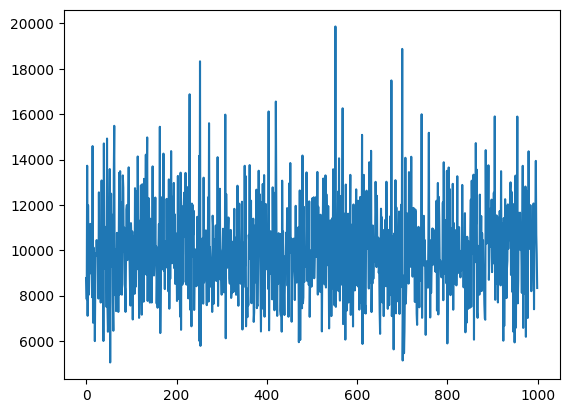

In [73]:
plt.plot(simulated_data)

In [52]:
# estimate model parameters from simulated data using sbi


def simulate(parameters):
    """
    Simulate Ricker model time series for given parameters.
    
    Parameters
    ----------
    parameters : array-like
        Array containing [r, k] parameters.
        r: intrinsic growth rate
        k: carrying capacity
    
    Returns
    -------
    torch.Tensor
        Time series of observed population values (shape: t_span,)
    """
    # Handle both single parameter sets and batches
    parameters = np.atleast_1d(parameters)
    if parameters.ndim == 2:
        parameters = parameters[0]  # Extract first parameter set from batch
    
    r = float(parameters[0])
    k = float(parameters[1])
    sigma = 0.2
    phi = 1.01

    y0 = 4000  # Initial population
    t_span = 100  # Total simulation time
    y = np.zeros(t_span)
    y[0] = y0

    N = y0  # Initialize N for the loop
    for i in range(1, t_span):
        N, y[i] = ricker_model(N, r, k, sigma, phi)

    # Convert to torch tensor for sbi compatibility
    return torch.as_tensor(y, dtype=torch.float32)

parameters = [1.2, 10000]
simulated_data = simulate(parameters)

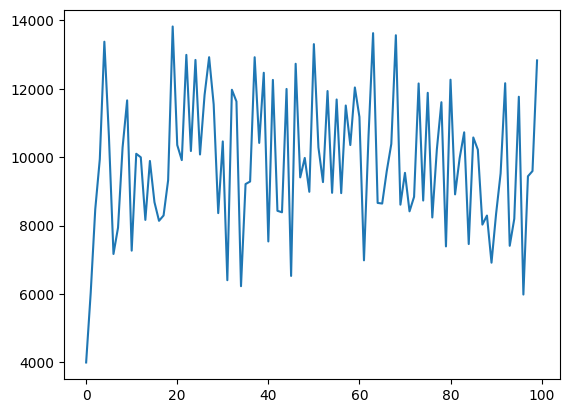

In [53]:
plt.plot(simulated_data)

In [54]:
# set up priors over parameters
import torch

_ = torch.manual_seed(42)
from sbi.utils import BoxUniform

lower_bound = torch.as_tensor([0.0, 5000])
upper_bound = torch.as_tensor([2.0, 15000])
prior = BoxUniform(low=lower_bound, high=upper_bound)

In [45]:
prior

BoxUniform(Uniform(low: torch.Size([2]), high: torch.Size([2])), 1)

In [55]:
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulation_wrapper = process_simulator(simulate, prior, prior_returns_numpy)
check_sbi_inputs(simulation_wrapper, prior)

In [59]:
theta, x = simulate_for_sbi(
    simulate, proposal=prior, num_simulations=1_000, num_workers=4
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [60]:
# Create inference object. Here, NPE is used.
inference = NPE(prior=prior)
inference = inference.append_simulations(theta, x)


AssertionError: Number of parameter sets (=1000 must match the number of simulation outputs (=100000)

### Estimate using autodiff 

In [ ]:
import torch
from torch import Tensor


def ricker_step(
    N: Tensor,
    r: Tensor,
    k: Tensor,
    sigma: float,
    phi: float,
    process_noise: Tensor,
    obs_noise: Tensor,
) -> tuple[Tensor, Tensor]:
    """Single step of Ricker model with pre-sampled noise."""
    N_next = N * torch.exp(r * (1 - N / k) + sigma * process_noise)
    # Gaussian approximation to Poisson: mean = N_next + phi, std = sqrt(N_next + phi)
    y_next = N_next + phi + torch.sqrt(N_next + phi) * obs_noise
    return N_next, y_next


def simulate(
    r: Tensor,
    k: Tensor,
    sigma: float = 0.2,
    phi: float = 1.01,
    y0: float = 4000.0,
    t_span: int = 100,
) -> Tensor:
    """Simulate Ricker model time series."""
    process_noise = torch.randn(t_span - 1)
    obs_noise = torch.randn(t_span - 1)

    N = torch.tensor(y0)
    y = torch.zeros(t_span)
    y[0] = y0 + phi + torch.sqrt(torch.tensor(y0 + phi)) * torch.randn(1)

    for t in range(t_span - 1):
        N, y[t + 1] = ricker_step(N, r, k, sigma, phi, process_noise[t], obs_noise[t])

    return y


def loss_fn(params: Tensor, observed: Tensor, n_sims: int = 10) -> Tensor:
    """MSE loss averaged over multiple simulations to reduce gradient variance."""
    r, k = params[0], params[1]
    total_loss = torch.tensor(0.0)

    for _ in range(n_sims):
        simulated = simulate(r, k)
        total_loss = total_loss + torch.mean((simulated - observed) ** 2)

    return total_loss / n_sims


def estimate(
    observed: Tensor,
    n_iter: int = 500,
    lr: float = 0.01,
    n_sims: int = 10,
) -> Tensor:
    """Estimate r and k via gradient descent."""
    log_params = torch.tensor([0.0, 8.5], requires_grad=True)
    optimizer = torch.optim.Adam([log_params], lr=lr)

    for i in range(n_iter):
        optimizer.zero_grad()
        params = torch.exp(log_params)
        loss = loss_fn(params, observed, n_sims)
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"iter {i:4d} | loss {loss.item():.1f} | r {params[0].item():.3f} | k {params[1].item():.0f}")

    return torch.exp(log_params).detach()

In [ ]:

estimate(torch.Tensor(simulated_data), n_iter=5000, lr=0.025, n_sims=10)

iter    0 | loss 32463812.0 | r 1.000 | k 4915
iter  100 | loss 8961683.0 | r 0.963 | k 9668
iter  200 | loss 9255571.0 | r 0.998 | k 9793
iter  300 | loss 9018555.0 | r 0.990 | k 9692
iter  400 | loss 8786898.0 | r 1.034 | k 9774
iter  500 | loss 9093182.0 | r 1.006 | k 9721
iter  600 | loss 8857360.0 | r 0.964 | k 9814
iter  700 | loss 8908137.0 | r 1.020 | k 9828
iter  800 | loss 9006524.0 | r 0.984 | k 9737
iter  900 | loss 9190318.0 | r 1.062 | k 9841


tensor([1.0236e+00, 9.6900e+03])

### synthetic likelihood

https://www.nature.com/articles/nature09319

